In [5]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [6]:
#imports

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

In [7]:
#fetch and clean data

from ucimlrepo import fetch_ucirepo

ckd = fetch_ucirepo(id=336)
df = pd.concat([ckd.data.features, ckd.data.targets], axis=1)

# Fix trailing whitespace in class column
df['class'] = df['class'].str.strip()

print(df.shape)
print(df['class'].value_counts())

(400, 25)
class
ckd       250
notckd    150
Name: count, dtype: int64


In [10]:
#handle missing columns

# Separate numeric and categorical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [11]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# First encode categoricals to numbers so KNN can work on them
df_encoded = df.copy()
le = LabelEncoder()
for col in cat_cols:
    df_encoded[col] = df_encoded[col].fillna('missing')
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Apply KNN imputation
imputer = KNNImputer(n_neighbors=5)
df_imputed_array = imputer.fit_transform(df_encoded)
df_imputed = pd.DataFrame(df_imputed_array, columns=df.columns)

print(df_imputed.isnull().sum().sum())  # should be 0

df=df_imputed

0


In [12]:
#split into features and target

X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(320, 24) (80, 24)


In [13]:
#hyperparameter training 

from sklearn.model_selection import GridSearchCV

rf_params = {
    'n_estimators': [30, 50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

#training RandomForest
rf_grid.fit(X_train, y_train)

print("Best RF params:", rf_grid.best_params_)
print("Best RF CV F1:", rf_grid.best_score_.round(4))

rf = rf_grid.best_estimator_  # replaces the old rf

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best RF params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best RF CV F1: 0.9872


In [14]:
#test RandomForest

rf_preds = rf.predict(X_test)
print("Random Forest")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(classification_report(y_test, rf_preds))

Random Forest
Accuracy: 0.9875
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99        50
         1.0       1.00      0.97      0.98        30

    accuracy                           0.99        80
   macro avg       0.99      0.98      0.99        80
weighted avg       0.99      0.99      0.99        80



In [15]:
#hyperparameter training

xgb_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_params,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

#training XGBoost

xgb_grid.fit(X_train, y_train)

print("Best XGB params:", xgb_grid.best_params_)
print("Best XGB CV F1:", xgb_grid.best_score_.round(4))

xgb = xgb_grid.best_estimator_  # replaces the old xgb

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best XGB params: {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 50}
Best XGB CV F1: 0.9874


In [20]:
#test XGBoost

xgb_preds = xgb.predict(X_test)
print("XGBoost")
print(f"Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")
print(classification_report(y_test, xgb_preds))

XGBoost
Accuracy: 1.0000
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        50
         1.0       1.00      1.00      1.00        30

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



NameError: name 'rf_proba' is not defined

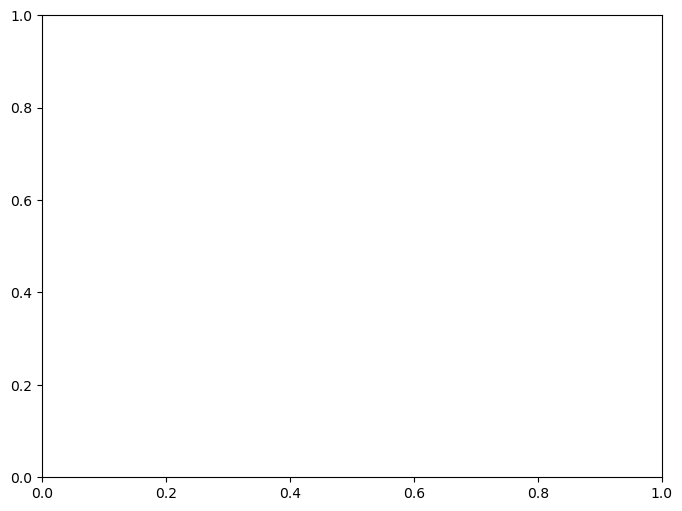

In [21]:
#plot ROC curve

from sklearn.metrics import RocCurveDisplay, roc_curve, auc
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

# Random Forest
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)
rf_auc = auc(rf_fpr, rf_tpr)
ax.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.4f})", 
        color="#1D9E75", linewidth=2)

# XGBoost
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_proba)
xgb_auc = auc(xgb_fpr, xgb_tpr)
ax.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {xgb_auc:.4f})", 
        color="#185FA5", linewidth=2)

# Diagonal baseline (random classifier)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", 
        linewidth=1, label="Random baseline")

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve — Random Forest vs XGBoost", fontsize=13)
ax.legend(loc="lower right", fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)  # saves it for your report
plt.show()

In [ ]:
#compare AUC values

rf_proba = rf.predict_proba(X_test)[:, 1]
xgb_proba = xgb.predict_proba(X_test)[:, 1]

print(f"AUC Values")
print(f"Random Forest:  {roc_auc_score(y_test, rf_proba):.4f}")
print(f"XGBoost:        {roc_auc_score(y_test, xgb_proba):.4f}")

In [ ]:
#save the better model
#joblib is used for parallel execution

import joblib

# saves whichever scored higher - in this case, XGBoost
joblib.dump(rf, 'ckd_model.pkl')
print("Random Forest Model saved.")

In [28]:
#installing SHAP

!pip install shap
import shap
import matplotlib.pyplot as plt

  Using cached numpy-2.0.2-cp312-cp312-macosx_14_0_arm64.whl.metadata (60 kB)
Using cached numpy-2.0.2-cp312-cp312-macosx_14_0_arm64.whl (5.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.


In [29]:
explainer_rf = shap.TreeExplainer(rf)

# This is what you should have — passing the full X_test
shap_values_rf_raw = explainer_rf.shap_values(X_test)
print(type(shap_values_rf_raw))
print(len(shap_values_rf_raw))           # should be 2
print(shap_values_rf_raw[0].shape)       # should be (80, 24)
print(shap_values_rf_raw[1].shape)       # should be (80, 24)

shap_values_rf = shap_values_rf_raw[1]  # class 1 = CKD
print(shap_values_rf.shape)             # should now be (80, 24)

<class 'numpy.ndarray'>
80
(24, 2)
(24, 2)
(24, 2)


In [32]:
#create the explainer

explainer_shap = shap.TreeExplainer(xgb)
shap_values = explainer_shap.shap_values(X_test)

In [36]:
shap_values_test = explainer_shap.shap_values(X_test)

# For Random Forest
if isinstance(shap_values_test, list):
    shap_values_test = np.array(shap_values_test[1])  # CKD class

np.save("shap_values_test.npy", shap_values_test)
print("Saved:", shap_values_test.shape)  # should be (80, 24)

Saved: (80, 24)


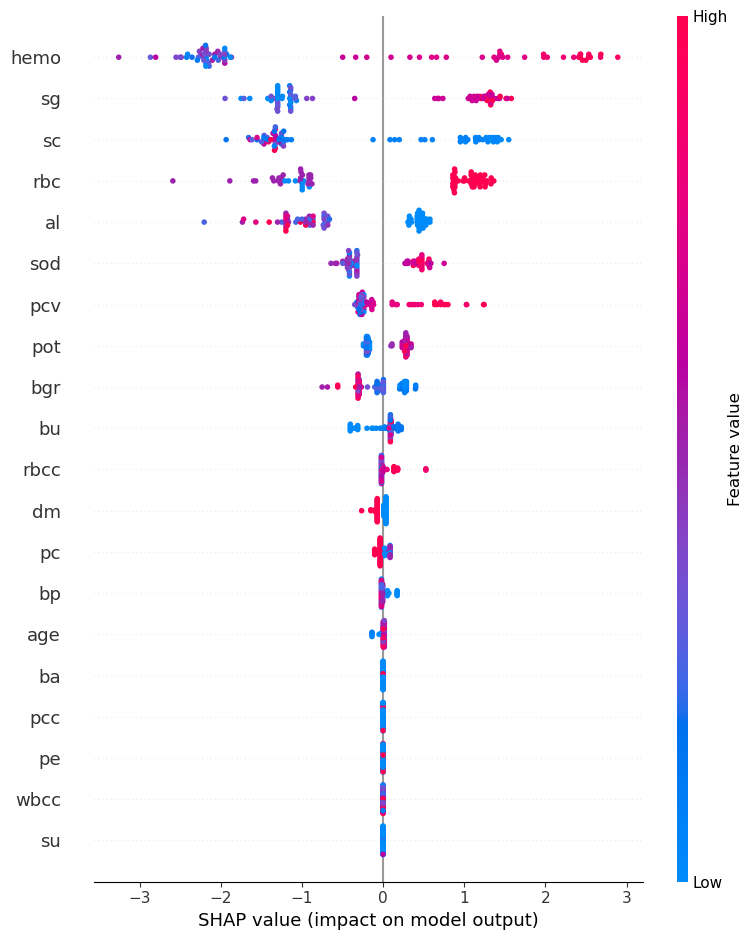

In [49]:
#global feature importance 
#This gives you a beeswarm plot showing which features matter most across all predictions, and in which direction. 
#This is your "global explainability" result 

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist())

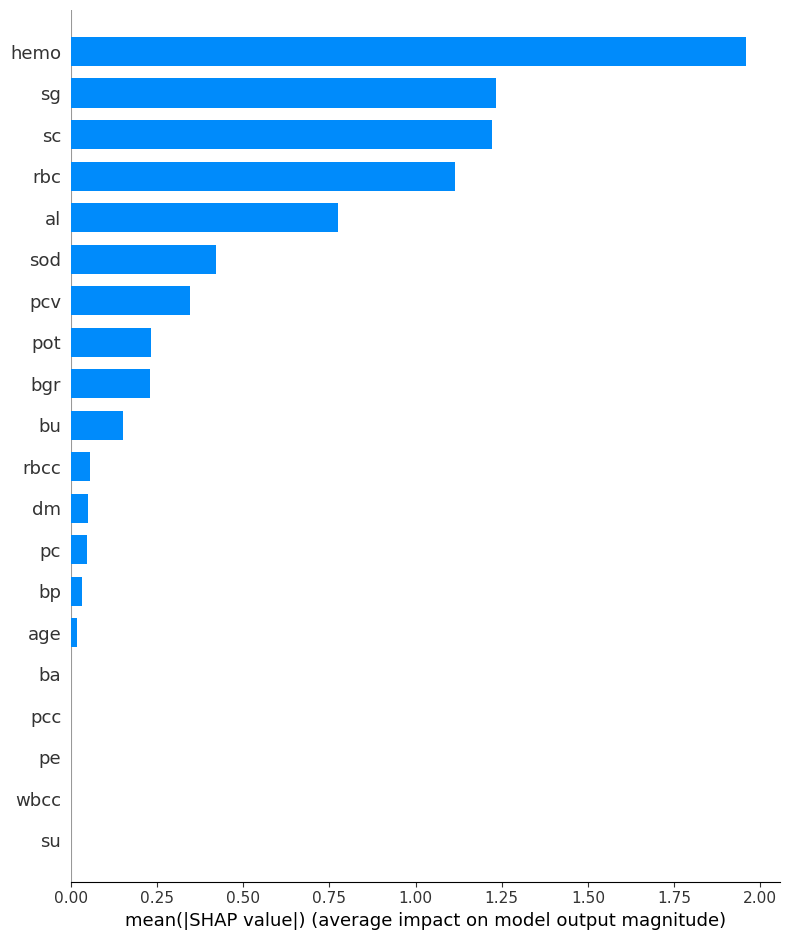

In [51]:
#bar chart (better for presentation)

shap.summary_plot(shap_values, X_test, 
                  feature_names=X.columns.tolist(), 
                  plot_type="bar")

In [53]:
# Global summary plot
shap.summary_plot(
    shap_values_rf, 
    X_test.values,                  # convert to numpy array
    feature_names=X.columns.tolist()
)

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

Expect haemoglobin, specific gravity, albumin, and serum creatinine to dominate — 
which aligns perfectly with clinical knowledge about CKD, and is something you can 
explicitly point out to your guide.


In [55]:
pip install lime

  Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl (13.7 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [56]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X.columns.tolist(),
    class_names=[str(c) for c in y.unique()],
    mode='classification'
)

In [59]:
i = 0  # index of instance
lime_exp = lime_explainer.explain_instance(
    data_row=X_test.iloc[i],
    predict_fn=xgb.predict_proba
)

/opt/anaconda3/lib/python3.12/site-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/opt/anaconda3/lib/python3.12/site-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/opt/anaconda3/lib/python3.12/site-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by positio

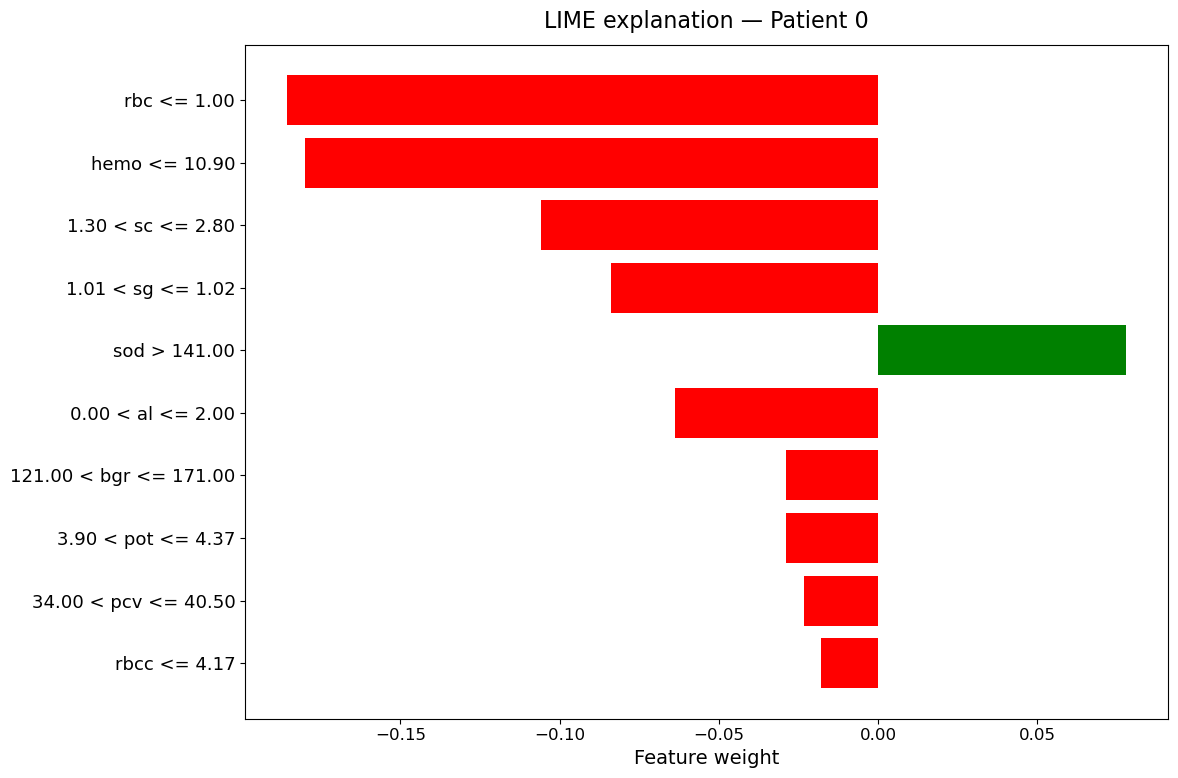

In [61]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 14

fig = lime_exp.as_pyplot_figure()
fig.set_size_inches(12, 8)

ax = fig.axes[0]
ax.set_xlabel("Feature weight", fontsize=14)
ax.set_title(f"LIME explanation — Patient {i}", fontsize=16, pad=12)

ax.tick_params(axis='y', labelsize=13)
ax.tick_params(axis='x', labelsize=12)

plt.tight_layout()
plt.savefig(f"lime_patient_{i}.png", dpi=150, bbox_inches='tight')
plt.show()

In [63]:
def build_shap_global_summary(shap_values, feature_names, X_test, top_n=10):
    # Mean absolute SHAP value per feature across all test patients
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    
    # Rank features
    ranked = sorted(
        zip(feature_names, mean_abs_shap),
        key=lambda x: x[1],
        reverse=True
    )[:top_n]
    
    lines = ["Global feature importance (averaged across all patients):"]
    for rank, (feat, importance) in enumerate(ranked, 1):
        lines.append(f"  {rank}. {feat}: mean |SHAP| = {importance:.4f}")
    
    # Also note direction for top 3
    lines.append("\nDirection of top 3 features:")
    for feat, _ in ranked[:3]:
        idx = feature_names.index(feat)
        mean_shap = shap_values[:, idx].mean()
        direction = "generally increases CKD risk" if mean_shap > 0 else "generally decreases CKD risk"
        lines.append(f"  - {feat}: {direction} (mean SHAP = {mean_shap:.4f})")
    
    return "\n".join(lines)


shap_global = build_shap_global_summary(
    shap_values, 
    X.columns.tolist(), 
    X_test
)
print(shap_global)

Global feature importance (averaged across all patients):
  1. hemo: mean |SHAP| = 1.9591
  2. sg: mean |SHAP| = 1.2322
  3. sc: mean |SHAP| = 1.2204
  4. rbc: mean |SHAP| = 1.1155
  5. al: mean |SHAP| = 0.7748
  6. sod: mean |SHAP| = 0.4213
  7. pcv: mean |SHAP| = 0.3456
  8. pot: mean |SHAP| = 0.2337
  9. bgr: mean |SHAP| = 0.2306
  10. bu: mean |SHAP| = 0.1502

Direction of top 3 features:
  - hemo: generally decreases CKD risk (mean SHAP = -0.4962)
  - sg: generally decreases CKD risk (mean SHAP = -0.1070)
  - sc: generally decreases CKD risk (mean SHAP = -0.2539)


In [65]:
def build_lime_local_summary(i, top_n=5):
    lime_exp = lime_explainer.explain_instance(
        X_test.iloc[i].values,
        xgb.predict_proba,
        num_features=top_n
    )

    prediction = xgb.predict(X_test.iloc[[i]])[0]
    probability = xgb.predict_proba(X_test.iloc[[i]])[0][prediction]
    outcome = "CKD detected" if prediction == 1 else "No CKD detected"
    
    lines = [
        f"Local explanation for Patient {i}:",
        f"  Prediction: {outcome} (confidence: {probability:.1%})",
        f"  Feature conditions that influenced this prediction:"
    ]
    
    for feat_condition, weight in lime_exp.as_list():
        direction = "toward CKD" if weight > 0 else "away from CKD"
        lines.append(
            f"  - {feat_condition}: weight = {weight:.4f} ({direction})"
        )
    
    return "\n".join(lines)


lime_local = build_lime_local_summary(12)
print(lime_local)

Local explanation for Patient 12:
  Prediction: CKD detected (confidence: 99.6%)
  Feature conditions that influenced this prediction:
  - hemo > 14.92: weight = 0.2876 (toward CKD)
  - 1.00 < rbc <= 2.00: weight = 0.1957 (toward CKD)
  - sc <= 0.90: weight = 0.1804 (toward CKD)
  - sg > 1.02: weight = 0.1677 (toward CKD)
  - al <= 0.00: weight = 0.1238 (toward CKD)


In [67]:
import anthropic
from dotenv import load_dotenv
import os
load_dotenv(dotenv_path="ANTHROPIC-API-KEY.env") #calling Claude API
client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))

In [71]:
def explain_patient(i, top_n=5):
    shap_global = build_shap_global_summary(
        shap_values, X.columns.tolist(), X_test, top_n
    )
    lime_local = build_lime_local_summary(i, top_n)
    
    prediction = xgb.predict(X_test.iloc[[i]])[0]
    probability = xgb.predict_proba(X_test.iloc[[i]])[0][prediction]
    outcome = "CKD detected" if prediction == 1 else "No CKD detected"

    print(f"Patient {i}: " + outcome)
    print('-'*20)

    prompt = f"""You are a clinical AI assistant helping a doctor understand 
a kidney disease risk prediction.

Patient prediction: {outcome} (confidence: {probability:.1%})

--- GLOBAL CONTEXT (SHAP across all patients) ---
This tells you which features matter most in general across the dataset.
Use this as background clinical context.
{shap_global}

--- LOCAL EXPLANATION (LIME for this specific patient) ---
This tells you why the model made this specific prediction for this patient.
This is the primary basis for your explanation.
{lime_local}

Write a clinical summary (4-5 sentences) that:
1. States the prediction and confidence
2. Explains this patient's specific risk factors using the LIME findings
3. Contextualises whether this patient's key drivers are typical 
   (i.e. do the LIME features match the globally important SHAP features, 
   or is this an unusual case?)
4. Notes any protective factors if present
5. Uses no ML terminology — written for a clinician

Flowing prose only, no bullet points."""

    message = client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=400,
        messages=[{"role": "user", "content": prompt}]
    )
    
    return message.content[0].text
    print(explain_patient(12))

explain_patient(73)

Patient 73: No CKD detected
--------------------


"# Clinical Summary – Patient 73\n\nThis patient has a very low risk of chronic kidney disease (CKD), with the model expressing 99.8% confidence in the absence of disease. Several protective factors are evident in this patient's profile. Low hemoglobin (≤10.90 g/dL) and elevated serum creatinine (>2.80 mg/dL) both work against CKD development in this case, alongside minimal albuminuria (≤2.00 mg/dL) and near-normal specific gravity (1.01–1.02), which collectively reduce the likelihood of renal dysfunction. One minor concern is a mildly elevated red blood cell count (1.00–2.00 million/μL), which slightly nudges the risk upward, though this effect is small relative to the protective factors.\n\nThe drivers of this low-risk classification align well with the general population patterns—hemoglobin and serum creatinine are among the most influential CKD predictors across all patients, and in this case they are favorably positioned. Overall, this patient's clinical profile suggests a reassur

In [ ]:
# Run this in your notebook and save the medians
# so the API can impute missing optional fields
import joblib

medians = {}
for col in X.columns:
    medians[col] = float(X[col].median())

joblib.dump(medians, "feature_medians.pkl")
print("Medians saved")